# Data collection

## Import dataset from Kaggle
    Sign Language MNIST
    ASL Alphabet

In [38]:
#!pip install kagglehub

> MNIST



In [39]:
import kagglehub

# Download the latest version of the dataset
path = kagglehub.dataset_download("datamunge/sign-language-mnist")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/sign-language-mnist


## Load libraries

In [40]:
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.utils import to_categorical
import os
from sklearn.model_selection import train_test_split

## Step 1 — Load the Data & Explore

In [41]:
train_df = pd.read_csv("/kaggle/input/sign-language-mnist/sign_mnist_train/sign_mnist_train.csv")
test_df = pd.read_csv("/kaggle/input/sign-language-mnist/sign_mnist_test/sign_mnist_test.csv")

In [42]:
#explore data
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (27455, 785)
Test shape: (7172, 785)


In [43]:
print('== train data == \n',train_df.head())
print('\n== test data ==\n',test_df.head())

== train data == 
    label  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  \
0      3     107     118     127     134     139     143     146     150   
1      6     155     157     156     156     156     157     156     158   
2      2     187     188     188     187     187     186     187     188   
3      2     211     211     212     212     211     210     211     210   
4     13     164     167     170     172     176     179     180     184   

   pixel9  ...  pixel775  pixel776  pixel777  pixel778  pixel779  pixel780  \
0     153  ...       207       207       207       207       206       206   
1     158  ...        69       149       128        87        94       163   
2     187  ...       202       201       200       199       198       199   
3     210  ...       235       234       233       231       230       226   
4     185  ...        92       105       105       108       133       163   

   pixel781  pixel782  pixel783  pixel784  
0       206

In [44]:
# check for missing values or duplicates on train
print("Train Missing values:", train_df.isnull().sum().sum())
print("Duplicates:", train_df.duplicated().sum())

# check for missing values or duplicates on test
print("Test Missing values:", test_df.isnull().sum().sum())
print("Duplicates:", test_df.duplicated().sum())

Train Missing values: 0
Duplicates: 0
Test Missing values: 0
Duplicates: 0


## Step 2 — Convert CSV to Image Files

In [45]:
def row_to_image(row):
    """Convert a row (pandas Series) into a 28x28 numpy image."""
    pixels = row.drop('label').values
    return pixels.reshape(28, 28)

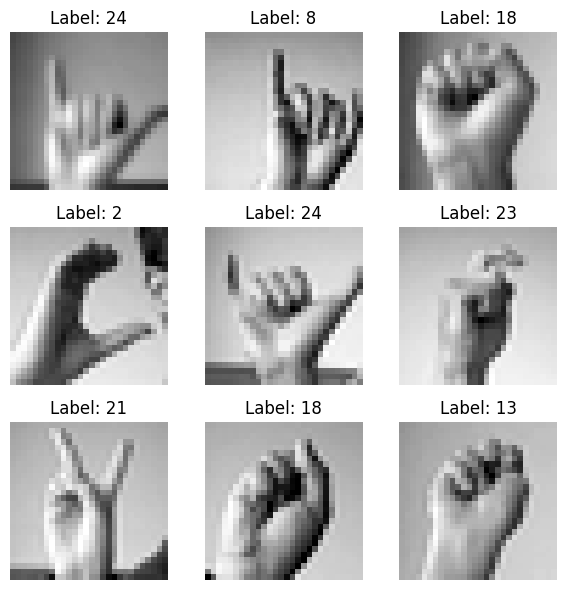

In [46]:
import matplotlib.pyplot as plt

# Pick 9 random samples
sample_df = train_df.sample(9, random_state=42)

plt.figure(figsize=(6, 6))
for i, (_, row) in enumerate(sample_df.iterrows()):
    img = row_to_image(row)
    label = row['label']
    plt.subplot(3, 3, i+1)
    plt.imshow(img, cmap='gray')
    plt.title(f"Label: {label}")
    plt.axis("off")
plt.tight_layout()
plt.show()

# Load Images from Folders

In [47]:
label_map = {
    0: 'A', 1: 'B', 2: 'C', 3: 'D', 4: 'E',
    5: 'F', 6: 'G', 7: 'H', 8: 'I', 10: 'K',
    11: 'L', 12: 'M', 13: 'N', 14: 'O', 15: 'P',
    16: 'Q', 17: 'R', 18: 'S', 19: 'T', 20: 'U',
    21: 'V', 22: 'W', 23: 'X', 24: 'Y'
}

# Preprocess train data

In [48]:
# Vectorized extraction of X and y
X = train_df.drop("label", axis=1).values.reshape(-1, 28, 28).astype(np.float32)
y = train_df["label"].map(label_map).values  # convert numeric → letter

In [49]:
print("X dtype before normalization:", X.dtype)

X dtype before normalization: float32


## Normalize + Train/Validation Split

In [50]:
# 2️⃣ Normalize only if needed
if X.max() > 1.0:
    X = X.astype(np.float32) / 255.0
else:
    X = X.astype(np.float32)  # just ensure float32 type

print("\nAfter normalization:")
print(f"X dtype: {X.dtype}, min: {X.min()}, max: {X.max()}")


After normalization:
X dtype: float32, min: 0.0, max: 1.0


# Preprocess test data

In [51]:
X_test = test_df.drop("label", axis=1).values.reshape(-1, 28, 28).astype(np.float32)
y_test = test_df["label"].map(label_map).values  # convert numeric -> letter

In [52]:
# Normalize
if X_test.max() > 1.0:
    X_test /= 255.0

In [53]:
print(f"✅ MNIST Test loaded: {X_test.shape}, Labels: {len(np.unique(y_test))}")
print(f"Pixel range: {X_test.min()} - {X_test.max()}")

✅ MNIST Test loaded: (7172, 28, 28), Labels: 24
Pixel range: 0.0 - 1.0


______________________________________________________________________________
# Second data
> ASL alphapet



In [54]:

# 1️⃣ Download ASL Alphabet dataset
asl_path = kagglehub.dataset_download("grassknoted/asl-alphabet")
print("Path to ASL dataset files:", asl_path)

Path to ASL dataset files: /kaggle/input/asl-alphabet


In [55]:
asl_train_dir = "/kaggle/input/asl-alphabet/asl_alphabet_train/asl_alphabet_train"

In [56]:
# جمع كل أسماء الفولدرات (A..Y)
classes_asl = sorted([d for d in os.listdir(os.path.join(asl_path, 'asl_alphabet_train/asl_alphabet_train')) if os.path.isdir(os.path.join(asl_path, 'asl_alphabet_train/asl_alphabet_train', d))])
# إزالة الـ dynamic signs J,Z
classes_asl = [cls for cls in classes_asl if cls not in ["J", "Z"]]

X_asl, y_asl = [], []

for cls in classes_asl:
    folder = os.path.join(asl_path, 'asl_alphabet_train/asl_alphabet_train', cls)
    for file in os.listdir(folder):
        img_path = os.path.join(folder, file)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue
        # Resize to 28x28 like MNIST
        img = cv2.resize(img, (28, 28))
        X_asl.append(img)
        y_asl.append(cls)

X_asl = np.array(X_asl, dtype=np.float32)

In [57]:
# Normalize
if X_asl.max() > 1.0:
    X_asl /= 255.0

In [58]:
# Reshape to 4D for CNN
X_asl = X_asl.reshape(-1, 28, 28, 1)
y_asl = np.array(y_asl)

print(f"✅ ASL Loaded: {X_asl.shape}, Labels: {len(np.unique(y_asl))}")
print("Pixel range:", X_asl.min(), "-", X_asl.max())

✅ ASL Loaded: (81000, 28, 28, 1), Labels: 27
Pixel range: 0.0 - 1.0


In [59]:
# 3️⃣ Sanity Check before Merge
# =========================

print(f"MNIST: {X.shape}, Labels: {len(np.unique(y))}, Classes: {sorted(np.unique(y))[:5]} ...")
print(f"ASL:   {X_asl.shape}, Labels: {len(np.unique(y_asl))}, Classes: {sorted(np.unique(y_asl))[:5]} ...")

print(f"MNIST Pixel range: {X.min()} - {X.max()}")
print(f"ASL   Pixel range: {X_asl.min()} - {X_asl.max()}")

MNIST: (27455, 28, 28), Labels: 24, Classes: ['A', 'B', 'C', 'D', 'E'] ...
ASL:   (81000, 28, 28, 1), Labels: 27, Classes: ['A', 'B', 'C', 'D', 'E'] ...
MNIST Pixel range: 0.0 - 1.0
ASL   Pixel range: 0.0 - 1.0


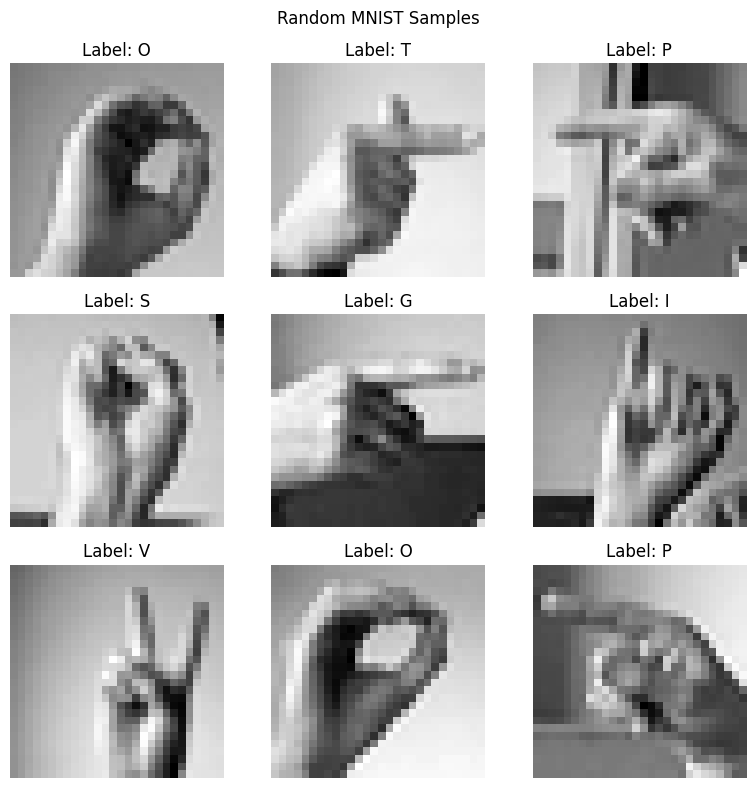

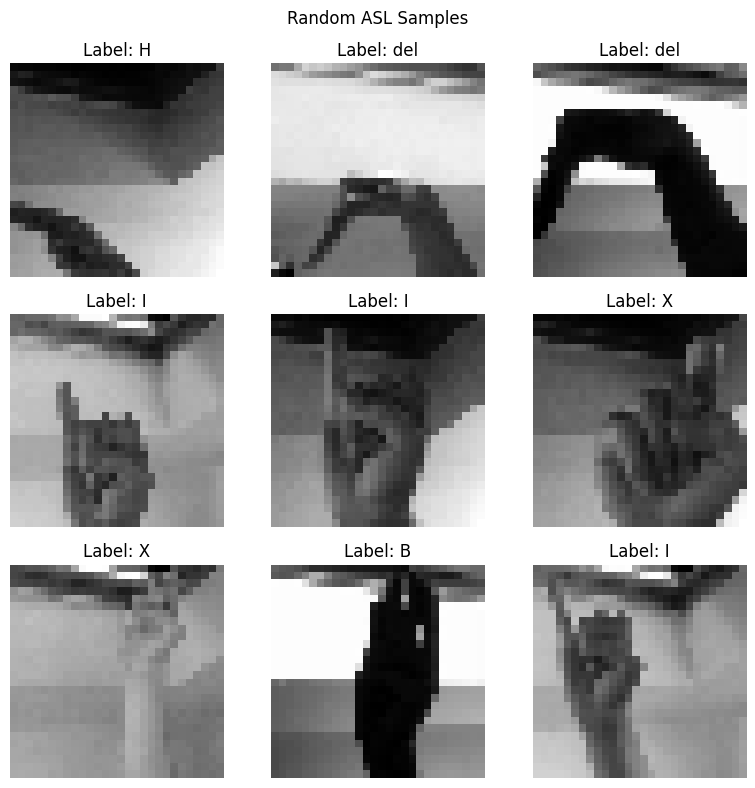

In [60]:
# Visualize few samples from MNIST
def visualize_samples(X, y, title, n=9):
    idxs = np.random.choice(len(X), n, replace=False)
    plt.figure(figsize=(8, 8))
    for i, idx in enumerate(idxs):
        plt.subplot(3, 3, i + 1)
        plt.imshow(X[idx].squeeze(), cmap="gray")
        plt.title(f"Label: {y[idx]}")
        plt.axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

visualize_samples(X, y, "Random MNIST Samples", n=9)
visualize_samples(X_asl, y_asl, "Random ASL Samples", n=9)

# Merging the 2 datasets

In [61]:
# =========================
# 4️⃣ Merge MNIST + ASL
# =========================
X_full = np.concatenate([X.reshape(-1, 28, 28, 1), X_asl], axis=0)
y_full = np.concatenate([y, y_asl], axis=0)

print(f"🔄 Combined Dataset: {X_full.shape}, Labels: {len(y_full)}")

🔄 Combined Dataset: (108455, 28, 28, 1), Labels: 108455


In [62]:
# Build final classes
all_classes = sorted(np.unique(y_full))
class_to_idx = {cls: idx for idx, cls in enumerate(all_classes)}

# Encode labels to integers
y_full_encoded = np.array([class_to_idx[lbl] for lbl in y_full])

In [63]:
# 5️⃣ Train/Val/Test Split
# =========================
X_train, X_temp, y_train_idx, y_temp_idx = train_test_split(
    X_full, y_full_encoded, test_size=0.2, stratify=y_full_encoded, random_state=42
)

X_val, X_test, y_val_idx, y_test_idx = train_test_split(
    X_temp, y_temp_idx, test_size=0.5, stratify=y_temp_idx, random_state=42
)

In [64]:
# 6️⃣ One-hot Encoding
# =========================
num_classes = len(all_classes)
y_train = to_categorical(y_train_idx, num_classes=num_classes)
y_val = to_categorical(y_val_idx, num_classes=num_classes)
y_test = to_categorical(y_test_idx, num_classes=num_classes)

print(f"✅ Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}, Classes: {num_classes}")

✅ Train: (86764, 28, 28, 1), Val: (10845, 28, 28, 1), Test: (10846, 28, 28, 1), Classes: 27


# Step 3: Data Augmentation Pipeline

In [65]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
print("✅ TensorFlow ImageDataGenerator is available and working.")

✅ TensorFlow ImageDataGenerator is available and working.


In [66]:
datagen = ImageDataGenerator(
    rotation_range=10,        # تدوير بسيط ±10 درجات
    zoom_range=0.1,          # Zoom 10%
    width_shift_range=0.1,   # إزاحة أفقية 10%
    height_shift_range=0.1,  # إزاحة عمودية 10%
    shear_range=0.1,         # Shear بزاوية 10 درجات
    horizontal_flip=False,  
    vertical_flip=False,
    fill_mode='nearest'
)
# Fit generator on training data
datagen.fit(X_train)

print("✅ Augmentation pipeline fitted on training data.")

✅ Augmentation pipeline fitted on training data.


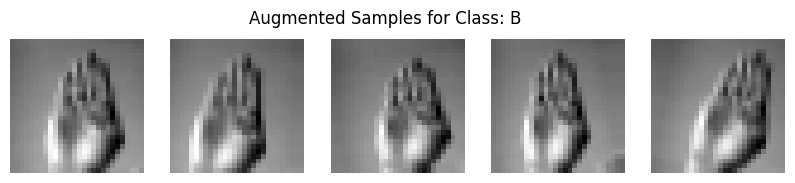

In [67]:
# 9️⃣ Visualization of Augmented Samples
sample_idx = np.random.randint(0, len(X_train))
x = X_train[sample_idx].reshape(1, 28, 28, 1)
true_label = all_classes[np.argmax(y_train[sample_idx])]

aug_iter = datagen.flow(x, batch_size=1)

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 2))
for i in range(5):
    batch = next(aug_iter)
    plt.subplot(1, 5, i + 1)
    plt.imshow(batch[0].reshape(28, 28), cmap="gray")
    plt.axis("off")

plt.suptitle(f"Augmented Samples for Class: {true_label}")
plt.show()

# Final check

In [68]:
import numpy as np
import matplotlib.pyplot as plt
import collections

print("🔎 FINAL DATA CHECK BEFORE TRAINING")

# 1️⃣ Shapes
print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
print(f"y shapes -> Train: {y_train.shape}, Val: {y_val.shape}, Test: {y_test.shape}")
print(f"Number of Classes: {len(all_classes)}, Classes: {all_classes}")

# 2️⃣ Pixel range check
print(f"Pixel range (Train): {X_train.min()} - {X_train.max()}")
print(f"Pixel range (ASL):   {X_asl.min()} - {X_asl.max()}")

🔎 FINAL DATA CHECK BEFORE TRAINING
Train: (86764, 28, 28, 1), Val: (10845, 28, 28, 1), Test: (10846, 28, 28, 1)
y shapes -> Train: (86764, 27), Val: (10845, 27), Test: (10846, 27)
Number of Classes: 27, Classes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'del', 'nothing', 'space']
Pixel range (Train): 0.0 - 1.0
Pixel range (ASL):   0.0 - 1.0


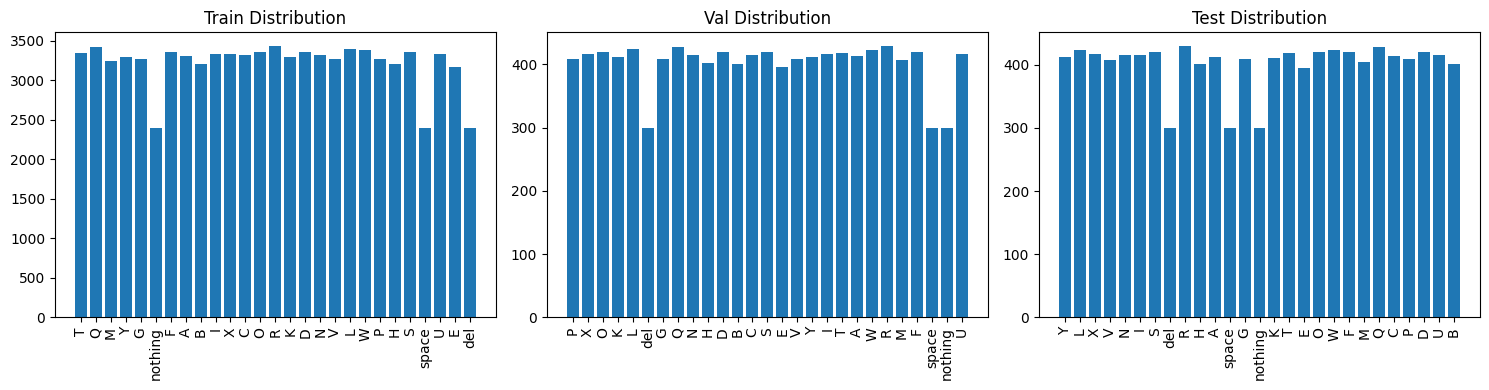

In [69]:
# 3️⃣ Class distribution check (Stratified?)
def plot_distribution(y_idx, title):
    counts = collections.Counter(y_idx)
    plt.bar([all_classes[i] for i in counts.keys()], counts.values())
    plt.title(title)
    plt.xticks(rotation=90)

plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1)
plot_distribution(np.argmax(y_train, axis=1), "Train Distribution")

plt.subplot(1, 3, 2)
plot_distribution(np.argmax(y_val, axis=1), "Val Distribution")

plt.subplot(1, 3, 3)
plot_distribution(np.argmax(y_test, axis=1), "Test Distribution")
plt.tight_layout()
plt.show()


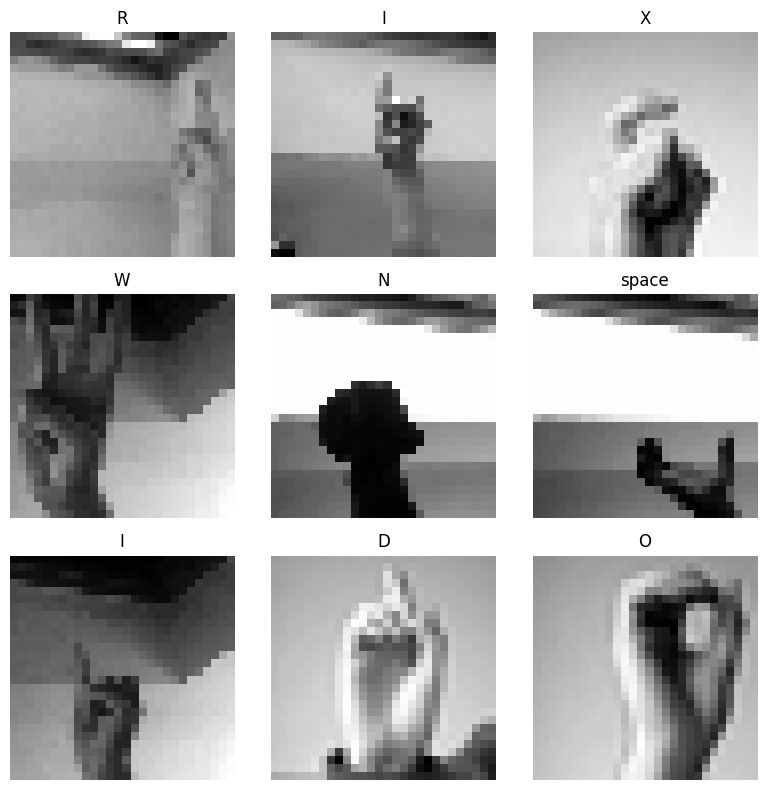

In [70]:
# 4️⃣ Sample visualization
def visualize_random_samples(X, y, classes, n=9):
    idxs = np.random.choice(len(X), n, replace=False)
    plt.figure(figsize=(8, 8))
    for i, idx in enumerate(idxs):
        plt.subplot(3, 3, i+1)
        plt.imshow(X[idx].squeeze(), cmap="gray")
        plt.title(classes[np.argmax(y[idx])])
        plt.axis("off")
    plt.tight_layout()
    plt.show()

visualize_random_samples(X_train, y_train, all_classes, n=9)

# ---------------------------------------------------------------------------------------------------------

# Imports 

In [71]:
pip install mlflow==2.12.1

Note: you may need to restart the kernel to use updated packages.


In [72]:
import mlflow

mlflow.set_tracking_uri("file:///kaggle/working/mlruns")
mlflow.set_experiment("cnn_monitoring")

<Experiment: artifact_location='file:///kaggle/working/mlruns/164230534176999985', creation_time=1764249779860, experiment_id='164230534176999985', last_update_time=1764249779860, lifecycle_stage='active', name='cnn_monitoring', tags={}>

In [73]:
import numpy as np
import mlflow.keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

# Load CNN model

In [78]:
from tensorflow import keras

model_path = "/kaggle/input/best-cnn/keras/default/1/best_cnn_model.h5"
model = keras.models.load_model(model_path)
model.summary()

2025-11-27 13:54:12.452020: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 26, 26, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 11, 11, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 11, 11, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 3, 3, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 1, 1, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 27)             │         6,939 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,557 (525.62 KB)

 Trainable params: 133,595 (521.86 KB)

 Non-trainable params: 960 (3.75 KB)

 Optimizer params: 2 (12.00 B)

# Prepare validation generator

In [79]:
BATCH_SIZE = 64

val_datagen = ImageDataGenerator()  # no augmentation for validation

val_gen = val_datagen.flow(
    X_val,
    y_val,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Evaluate model and get predictions

In [80]:
preds = model.predict(val_gen)
y_pred = np.argmax(preds, axis=1)
y_true = np.argmax(y_val, axis=1)

accuracy = (y_pred == y_true).mean()
print(f"\n Validation Accuracy: {accuracy:.4f}\n")

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


170/170 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step

 Validation Accuracy: 0.9785



# Classification report

In [81]:
report = classification_report(y_true, y_pred, target_names=all_classes, output_dict=True)
print(classification_report(y_true, y_pred, target_names=all_classes))

              precision    recall  f1-score   support

           A       0.97      0.97      0.97       413
           B       0.94      0.98      0.96       401
           C       1.00      1.00      1.00       415
           D       0.99      0.98      0.98       419
           E       0.99      0.95      0.97       396
           F       1.00      1.00      1.00       420
           G       1.00      0.98      0.99       409
           H       0.98      1.00      0.99       402
           I       0.98      0.99      0.99       416
           K       0.97      0.99      0.98       412
           L       1.00      0.98      0.99       424
           M       0.98      0.95      0.97       406
           N       0.96      0.98      0.97       415
           O       1.00      0.99      0.99       419
           P       0.99      1.00      0.99       409
           Q       0.98      1.00      0.99       428
           R       0.96      0.94      0.95       429
           S       0.93    

# Confusion matrix

Confusion matrix shape: (27, 27)


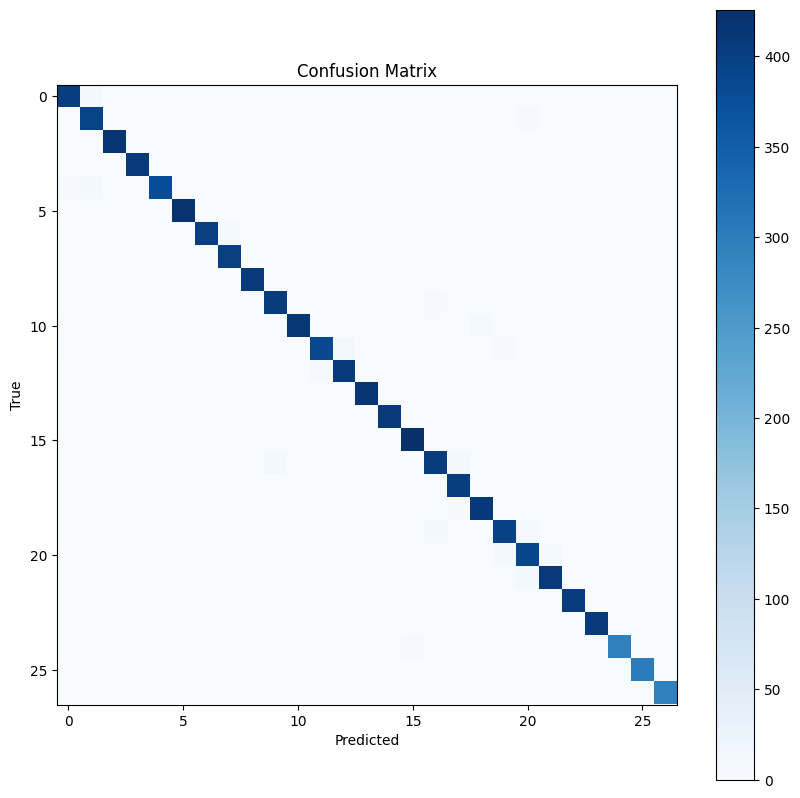

In [82]:
cm = confusion_matrix(y_true, y_pred)
print("Confusion matrix shape:", cm.shape)

plt.figure(figsize=(10, 10))
plt.imshow(cm, cmap='Blues')
plt.title("Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# Log metrics & artifacts to MLflow

In [83]:
with mlflow.start_run():
    # Log validation accuracy
    mlflow.log_metric("validation_accuracy", float(accuracy))
    
    # Log confusion matrix as an artifact
    np.save("confusion_matrix.npy", cm)
    mlflow.log_artifact("confusion_matrix.npy")
    
    # Optional: log classification report as JSON
    import json
    with open("classification_report.json", "w") as f:
        json.dump(report, f, indent=4)
    mlflow.log_artifact("classification_report.json")
    
    print("Validation metrics and artifacts logged to MLflow")

Validation metrics and artifacts logged to MLflow


# Log additional metrics

*Besides overall accuracy, you can log per-class metrics (precision, recall, F1) as separate metrics*

In [84]:
import mlflow

per_class_metrics = {
    "precision_A": 0.97,
    "recall_A": 0.97,
    "f1_A": 0.97,
    # ... add all classes
}

with mlflow.start_run():
    for key, value in per_class_metrics.items():
        mlflow.log_metric(key, value)

# Log sample predictions

*Save some images with predicted vs true labels*

In [85]:
import numpy as np
for i in range(5):
    plt.imshow(X_val[i].reshape(28,28), cmap="gray")
    plt.title(f"True: {all_classes[y_true[i]]}, Pred: {all_classes[y_pred[i]]}")
    plt.axis("off")
    plt.savefig(f"sample_pred_{i}.png")
    mlflow.log_artifact(f"sample_pred_{i}.png")
    plt.close()

# Track hyperparameters

*If you know your training batch size, learning rate, augmentation settings, etc., log them*

In [86]:
mlflow.log_param("batch_size", 64)
mlflow.log_param("learning_rate", 0.001)
mlflow.log_param("epochs", 20)
mlflow.log_param("augmentation", "rotation, zoom, shift")

'rotation, zoom, shift'

# Version the dataset

*Save a small hash or summary of your training data in MLflow*

In [87]:
import hashlib
data_hash = hashlib.md5(X_train.tobytes()).hexdigest()
mlflow.log_param("train_data_hash", data_hash)

'ae6888921380cd6b530ae57419c57cf9'